<a href="https://colab.research.google.com/github/Ashcodes69/Models/blob/main/Speech_Emotion_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[Dataset Download link]( https://zenodo.org/record/1188976)

# Load Google drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## Unzip the file

In [ ]:
!unzip -q "/content/drive/MyDrive/Audio_Speech_Actors_01-24.zip" -d "/content/audio_data"


# Explore the Data

In [ ]:

# Modality - Vocal Channel - Emotion - Emotional Intensity - Statement - Repetition - Actor .wav
import os
import collections

# Path to your RAVDESS audio directory
data_dir = "/content/audio_data"

# Mapping dictionary for visualization
emotion_map = {
    "01": "Neutral", "02": "Calm", "03": "Happy", "04": "Sad",
    "05": "Angry", "06": "Fearful", "07": "Disgust", "08": "Surprised"
}

emotion_counts = collections.Counter()

# Scan files and extract the 3rd token (index 2)
for root, _, files in os.walk(data_dir):
    for file in files:
        if file.endswith(".wav"):
            tokens = file.split("-")
            if len(tokens) >= 3:
                emotion_code = tokens[2]
                emotion_name = emotion_map.get(emotion_code, "Unknown")
                emotion_counts[emotion_name] += 1

# Print the final balance results
print("--- RAVDESS Class Distribution ---")
for emotion, count in sorted(emotion_counts.items()):
    print(f"{emotion:<10}: {count} files")


--- RAVDESS Class Distribution ---
Angry     : 192 files
Calm      : 192 files
Disgust   : 192 files
Fearful   : 192 files
Happy     : 192 files
Neutral   : 96 files
Sad       : 192 files
Surprised : 192 files


# Convert it to Dataframe

In [ ]:
import pandas as pd
import os

data_dir = "/content/audio_data"

emotion_map = {
    "01": "Neutral", "02": "Calm", "03": "Happy", "04": "Sad",
    "05": "Angry", "06": "Fearful", "07": "Disgust", "08": "Surprised"
}

rows = []

for root, _, files in os.walk(data_dir):
    for file in files:
        if file.endswith(".wav"):
            tokens = file.split("-")

            if len(tokens) == 7:
                emotion_code = tokens[2]

                actor_id = int(tokens[6].split(".")[0])

                emotion = emotion_map.get(emotion_code, "Unknown")

                emotion_code = int(emotion_code) - 1

                if actor_id <= 16:
                    self_assignment = "train"
                elif actor_id > 16 and actor_id <= 20:
                    self_assignment = "val"
                else:
                    self_assignment = "test"

                full_path = os.path.join(root, file)

                rows.append({
                    "file_path": full_path,
                    "emotion": emotion,
                    "emotion_label": emotion_code,
                    "actor_id": actor_id,
                    "split": self_assignment
                })


df = pd.DataFrame(rows)

print(df.head())


                                           file_path    emotion  \
0  /content/audio_data/Actor_06/03-01-04-02-01-01...        Sad   
1  /content/audio_data/Actor_06/03-01-08-01-02-02...  Surprised   
2  /content/audio_data/Actor_06/03-01-02-01-01-02...       Calm   
3  /content/audio_data/Actor_06/03-01-03-01-01-02...      Happy   
4  /content/audio_data/Actor_06/03-01-07-02-02-02...    Disgust   

   emotion_label  actor_id  split  
0              3         6  train  
1              7         6  train  
2              1         6  train  
3              2         6  train  
4              6         6  train  


### Explore the DataFrame

In [ ]:
print('Num of actors in train, val, test-------\n')
print(df.groupby("split")["actor_id"].nunique())

print("\n")
print(df.groupby("split")["actor_id"].apply(lambda ids: f"Male: {sum(id % 2 != 0 for id in set(ids))}, Female: {sum(id % 2 == 0 for id in set(ids))}"))

print("\n")
# Create a cross-tab table comparing splits against emotional labels
distribution_matrix = pd.crosstab(df["emotion"], df["split"])

# Display the matrix ordered logically
print(distribution_matrix)

Num of actors in train, val, test-------

split
test      4
train    16
val       4
Name: actor_id, dtype: int64


split
test     Male: 2, Female: 2
train    Male: 8, Female: 8
val      Male: 2, Female: 2
Name: actor_id, dtype: object


split      test  train  val
emotion                    
Angry        32    128   32
Calm         32    128   32
Disgust      32    128   32
Fearful      32    128   32
Happy        32    128   32
Neutral      16     64   16
Sad          32    128   32
Surprised    32    128   32


#Mel spectrogram

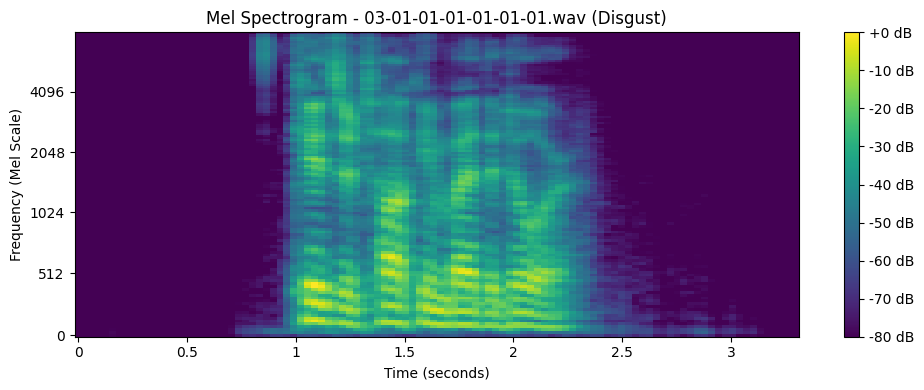

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

file_path = "/content/audio_data/Actor_01/03-01-01-01-01-01-01.wav"

y, sr = librosa.load(file_path, sr=16000)

mel_spectrogram = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)

mel_s_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_s_db, sr=sr, x_axis="time", y_axis="mel", cmap="viridis")

plt.colorbar(format='%+2.0f dB')
plt.title(f"Mel Spectrogram - {file_path.split('/')[-1]} (Disgust)", fontsize=12)
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Mel Scale)")
plt.tight_layout()
plt.show()


In [ ]:
import torch
import torchvision.transforms as TV
import torchaudio.transforms as TA

class Train_transform_class:
    def __init__(self, size=(224,224),  mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
        self.time_mask = TA.TimeMasking(time_mask_param=25)
        self.freq_mask = TA.FrequencyMasking(freq_mask_param=15)

        self.resize = TV.Resize(size=size, antialias=True)
        self.normalize = TV.Normalize(mean=mean, std=std)


    def __call__(self, mel_norm_np):
        # Convert raw numpy spectrogram to a PyTorch float tensor -> (1, 128, 188)
        tensor = torch.tensor(mel_norm_np, dtype=torch.float32).unsqueeze(0)

        # Step A: Apply Audio Data Augmentation (SpecAugment)
        tensor = self.time_mask(tensor)
        tensor = self.freq_mask(tensor)

        # Step B: Convert to 3-Channel RGB -> (3, 128, 188)
        tensor = tensor.repeat(3, 1, 1)

        # Step C: Resize and Standardize for EfficientNet -> (3, 224, 224)
        tensor = self.resize(tensor)
        tensor = self.normalize(tensor)


        return tensor

class Val_test_transform_class:
    def __init__(self, size=(224,224),  mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]):
        self.resize = TV.Resize(size=size, antialias=True)
        self.normalize = TV.Normalize(mean=mean, std=std)

    def __call__(self, mel_norm_np):
        tensor = torch.tensor(mel_norm_np, dtype=torch.float32,).unsqueeze(0)
        tensor = tensor.repeat(3, 1, 1)
        tensor = self.resize(tensor)
        tensor = self.normalize(tensor)

        return tensor

train_transform = Train_transform_class()
val_test_transform = Val_test_transform_class()

In [ ]:
import torch
import librosa
import numpy as np
from torch.utils.data import Dataset

class RavdessDataset(Dataset):
    def __init__(self, df, transform=None, target_duration=3.0, sr=16000, n_mels=128, hop_length=256, fmax=8000):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.target_duration = target_duration
        self.sr = sr
        self.n_mels = n_mels
        self.hop_length = hop_length
        self.fmax = fmax
        self.target_samples = int(target_duration * sr)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # 1. Gather file path and label metadata
        row = self.df.iloc[idx]
        file_path = row["file_path"]
        class_idx = row["emotion_label"]

        # 2. Load and downsample audio
        y   , _ = librosa.load(file_path, sr = self.sr)

        # 3. Trim silence padding
        y, _ = librosa.effects.trim(y, top_db=25)

        # 4. Force length to exactly 3.0 seconds (48,000 samples)
        if len(y) < self.target_samples:
            pad_width = self.target_samples - len(y)
            y = np.pad(y, (0, pad_width), mode="constant")
        else:
            start_idx = (len(y) - self.target_samples) // 2
            end_idx = start_idx + self.target_samples
            y = y[start_idx:end_idx]

        # 5. Extract Mel Spectrogram (produces height=128, width=188)
        mel_spec = librosa.feature.melspectrogram(
            y=y, sr=self.sr, n_mels = self.n_mels,
            hop_length=self.hop_length, fmax= self.fmax
        )

        # 6. Convert to Log Decibels
        mel_db = librosa.power_to_db(mel_spec, ref=np.max)

        # 7. Normalize values between 0.0 and 1.0
        mel_db = np.clip(mel_db, -80.0, 0.0)
        mel_norm = (mel_db - (-80.0)) / (0.0 - (-80.0))

        # 8. Hand the raw 2D array off to our external transform object
        if self.transform is not None:
            tensor_final = self.transform(mel_norm)
        else:
            tensor_final = torch.tensor(mel_norm, dtype=torch.float32).unsqueeze(0).repeat(3, 1, 1)

        return tensor_final, torch.tensor(class_idx, dtype=torch.long)

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE= 32

train_loader = DataLoader(
    dataset= RavdessDataset(df=df[df['split'] == 'train'], transform=train_transform),
    batch_size= BATCH_SIZE,
    shuffle= True,
    drop_last= True
)

val_loader = DataLoader(
    dataset= RavdessDataset(df[df['split'] == 'val'], transform=val_test_transform),
    batch_size= BATCH_SIZE,
    shuffle= False
)

test_loader = DataLoader(
    dataset= RavdessDataset(df[df['split'] == 'test'], transform=val_test_transform),
    batch_size= BATCH_SIZE,
    shuffle= False
)

print(f"Total Training Batches   : {len(train_loader)}")
print(f"Total Validation Batches : {len(val_loader)}")
print(f"Total Testing Batches    : {len(test_loader)}")

Total Training Batches   : 30
Total Validation Batches : 8
Total Testing Batches    : 8


In [ ]:
train_counts = distribution_matrix['train'].sort_index().values
count_tensor = torch.tensor(train_counts, dtype=torch.float32)
weights = 1.0 / count_tensor
weights = (weights / weights.sum()) * len(train_counts)
print(weights)
print(distribution_matrix['train'].sort_index())

tensor([0.8889, 0.8889, 0.8889, 0.8889, 0.8889, 1.7778, 0.8889, 0.8889])
emotion
Angry        128
Calm         128
Disgust      128
Fearful      128
Happy        128
Neutral       64
Sad          128
Surprised    128
Name: train, dtype: int64


In [ ]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

model = efficientnet_b3(weights= EfficientNet_B3_Weights.DEFAULT)

In [ ]:
for param in model.parameters():
    param.requires_grad = False

In [ ]:
in_features = model.classifier[1].in_features
hidden_dim = 512

model.classifier = nn.Sequential(
    nn.Linear(in_features=in_features, out_features=hidden_dim),
    nn.BatchNorm1d(num_features=hidden_dim),
    nn.ReLU(),
    nn.Dropout(p=0.4),

    nn.Linear(in_features=hidden_dim, out_features=8)
)

In [ ]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = model.to(device)
criterion = torch.nn.CrossEntropyLoss(weight=weights.to(device))
optimizer = torch.optim.Adam(params=model.classifier.parameters(), lr= 1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

In [ ]:
from math import isnan
import numpy as np
import torch

class EarlyStopping:
    def __init__(self, patience=4, min_delta=0, save_path = "best_emotion_model.pth"):
        self.patience = patience
        self.min_delta = min_delta
        self.save_path = save_path
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False

    def __call__(self, val_loss, model):
        # If val_loss is NaN, ignore or treat as no improvement
        if np.isnan(val_loss):
            return

        if val_loss < self.best_loss - self.min_delta:
        # Significant improvement detected! Save weights and reset counter
            self.best_loss = val_loss
            self.save_checkpoint(model)
            self.counter = 0
            print("Validation loss decreassed saving optimized model weights...")
        else:
            # No improvement
            self.counter += 1
            print(f"EarlyStoping counter {self.counter} out of {self.patience}")

            if self.counter >= self.patience:
                self.early_stop = True

    def save_checkpoint(self, model):
        # Saves model when validation loss decreases.
        torch.save(model.state_dict(), self.save_path)

    def load_checkpoint(self, model):
        model.load_state_dict(torch.load(self.save_path))

In [ ]:
import time
import os
import torch

def train(
        model, optimizer, criterion, scheduler,
        epochs, train_loader, val_loader,
        cheackpoint_dir="/content/drive/MyDrive/checkpoints"
        ):
    early_stopping = EarlyStopping()

    os.makedirs(cheackpoint_dir, exist_ok=True)

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }

    print(f"{'=' * 60}\nTRAINING STARTED\n{'=' * 60}")
    time_start = time.time()

    for epoch in range(epochs):
        model.train()

        train_loss, train_correct = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_correct += (outputs.argmax(1) == labels).sum().item()

        model.eval()
        val_loss, val_correct = 0, 0
        with torch.inference_mode():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()



        train_loss_avg = train_loss / len(train_loader)
        val_loss_avg = val_loss / len(val_loader)

        train_acc = 100 * train_correct / len(train_loader.dataset)
        val_acc = 100 * val_correct / len(val_loader.dataset)


        history['train_loss'].append(train_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train loss: {train_loss_avg:.4f} | Train acc: {train_acc:.2f}% | "
            f"Val loss: {val_loss_avg:.4f} | Val acc: {val_acc:.2f}%"
            )

        # Save cheackpoint.
        checkpoint_path = os.path.join(cheackpoint_dir, f"checkpoint_epoch_{epoch + 1}.pth")
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "history": history
        }, checkpoint_path)

        # Remove previous checkpoint.
        prev_checkpoint = os.path.join(cheackpoint_dir, f"checkpoint_epoch_{epoch}.pth")
        if os.path.exists(prev_checkpoint):
            os.remove(prev_checkpoint)

        print(f"Cheackpoint saved: epoch {epoch + 1}")

        scheduler.step(val_loss_avg)

        # Early stoping if model not shows progress
        early_stopping(val_loss_avg, model)

        if early_stopping.early_stop:
            print(f"\nEarly stoping triggerd Training stopped at epoch {epoch + 1}")
            print("\nRestroing structural model to its peak optimized weight parameters...")
            early_stopping.load_checkpoint(model)
            break


    total_time = time.time() - time_start
    print(f"{'=' * 60}\nTraining Complete! Total time: {total_time/60:.2f} mins\n{'=' * 60}")

    return history

# Verify everything is correct before start training

In [ ]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable} / Total: {total}")

print(model.classifier)

for pg in optimizer.param_groups:
    print(f"Params in optimizer: {len(pg['params'])}, LR: {pg['lr']}")


Trainable: 792072 / Total: 11488304
Sequential(
  (0): Linear(in_features=1536, out_features=512, bias=True)
  (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.4, inplace=False)
  (4): Linear(in_features=512, out_features=8, bias=True)
)
Params in optimizer: 6, LR: 0.0005


# TRAIN PHASE- 1.

In [ ]:
history_phase1 = train(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    epochs=10,
    train_loader=train_loader,
    val_loader=val_loader,
    cheackpoint_dir="/content/drive/MyDrive/checkpoints_phase1"
)

TRAINING STARTED
Epoch [1/10] | Train loss: 1.9529 | Train acc: 24.17% | Val loss: 1.8493 | Val acc: 21.67%
Cheackpoint saved: epoch 1
Validation loss decreassed saving optimized model weights...
Epoch [2/10] | Train loss: 1.6270 | Train acc: 36.98% | Val loss: 1.7864 | Val acc: 30.42%
Cheackpoint saved: epoch 2
Validation loss decreassed saving optimized model weights...
Epoch [3/10] | Train loss: 1.5716 | Train acc: 39.06% | Val loss: 1.7327 | Val acc: 27.50%
Cheackpoint saved: epoch 3
Validation loss decreassed saving optimized model weights...
Epoch [4/10] | Train loss: 1.4853 | Train acc: 42.50% | Val loss: 1.6062 | Val acc: 38.33%
Cheackpoint saved: epoch 4
Validation loss decreassed saving optimized model weights...
Epoch [5/10] | Train loss: 1.4517 | Train acc: 45.21% | Val loss: 1.5708 | Val acc: 37.92%
Cheackpoint saved: epoch 5
Validation loss decreassed saving optimized model weights...
Epoch [6/10] | Train loss: 1.3957 | Train acc: 46.88% | Val loss: 1.5524 | Val acc: 42.5

# PHASE - 2 preprations

In [ ]:
# Unfreezing architecture with Differential Learning Rates for Phase 2...
for param in model.parameters():
    param.requires_grad = True

optimizer_phase2 = torch.optim.Adam([
    {'params': model.features.parameters(), 'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-4}
])

scheduler_phase2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer_phase2,
    mode='min',
    factor=0.5,
    patience = 3
)

early_stopping = EarlyStopping(patience=7, save_path="/content/drive/MyDrive/checkpoints/best_emotion_model.pth")


# Verify everything before PHASE: 2 Training

In [ ]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable} / Total: {total}")

print(model.classifier)

for pg in optimizer_phase2.param_groups:
    print(f"Params in optimizer: {len(pg['params'])}, LR: {pg['lr']}")


Trainable: 11488304 / Total: 11488304
Sequential(
  (0): Linear(in_features=1536, out_features=512, bias=True)
  (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.4, inplace=False)
  (4): Linear(in_features=512, out_features=8, bias=True)
)
Params in optimizer: 338, LR: 1e-05
Params in optimizer: 6, LR: 0.0001


# TRAIN PHASE - 2

In [ ]:
history_phase2 = train(
    model=model,
    optimizer=optimizer_phase2,
    criterion=criterion,
    scheduler=scheduler_phase2,
    epochs=35,
    train_loader=train_loader,
    val_loader=val_loader,
    cheackpoint_dir="/content/drive/MyDrive/checkpoints_phase2"
)

TRAINING STARTED
Epoch [1/35] | Train loss: 1.3906 | Train acc: 46.25% | Val loss: 1.5153 | Val acc: 45.42%
Cheackpoint saved: epoch 1
Validation loss decreassed saving optimized model weights...
Epoch [2/35] | Train loss: 1.3083 | Train acc: 50.21% | Val loss: 1.5198 | Val acc: 44.17%
Cheackpoint saved: epoch 2
EarlyStoping counter 1 out of 4
Epoch [3/35] | Train loss: 1.2691 | Train acc: 51.15% | Val loss: 1.5034 | Val acc: 44.17%
Cheackpoint saved: epoch 3
Validation loss decreassed saving optimized model weights...
Epoch [4/35] | Train loss: 1.2702 | Train acc: 52.08% | Val loss: 1.5043 | Val acc: 46.25%
Cheackpoint saved: epoch 4
EarlyStoping counter 1 out of 4
Epoch [5/35] | Train loss: 1.2503 | Train acc: 53.02% | Val loss: 1.4948 | Val acc: 42.92%
Cheackpoint saved: epoch 5
Validation loss decreassed saving optimized model weights...
Epoch [6/35] | Train loss: 1.1860 | Train acc: 56.77% | Val loss: 1.4944 | Val acc: 43.75%
Cheackpoint saved: epoch 6
Validation loss decreassed s

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch  # Ensure torch is explicitly present in this cell's scope

def evaluate_model(model, dataloader, split_name="TEST"):
    model.eval()
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.inference_mode():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    all_probs = np.vstack(all_probs)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    class_names = ["Angry", "Calm", "Disgust", "Fearful", "Happy", "Neutral", "Sad", "Surprised"]

    print("=" * 60)
    print(f"📊 PERFORMANCE METRICS REPORT: {split_name} SET")
    print("=" * 60)
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

    # AUC-ROC per class with safety protection
    print("=" * 60)
    print("AUC-ROC PER CLASS")
    print("=" * 60)
    for i, class_name in enumerate(class_names):
        y_true_binary = (all_labels == i).astype(int)
        # Check if the binary target has both classes present (0 and 1)
        if len(np.unique(y_true_binary)) > 1:
            auc = roc_auc_score(y_true_binary, all_probs[:, i])
            print(f"{class_name:<10}: {auc:.4f}")
        else:
            print(f"{class_name:<10}: N/A (No samples present in this data split)")

    # Confusion matrix
    print("=" * 60)
    print("CONFUSION MATRIX")
    print("=" * 60)
    cm = confusion_matrix(all_labels, all_preds)

    # Build Confusion Matrix Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"Confusion Matrix Heatmap ({split_name} Split)")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.tight_layout()
    plt.show()

    return all_labels, all_preds

📊 PERFORMANCE METRICS REPORT: TEST SET
              precision    recall  f1-score   support

       Angry       0.25      0.25      0.25        16
        Calm       0.56      0.69      0.62        32
     Disgust       0.41      0.28      0.33        32
     Fearful       0.31      0.16      0.21        32
       Happy       0.50      0.62      0.56        32
     Neutral       0.74      0.44      0.55        32
         Sad       0.42      0.69      0.52        32
   Surprised       0.69      0.78      0.74        32

    accuracy                           0.50       240
   macro avg       0.49      0.49      0.47       240
weighted avg       0.50      0.50      0.49       240

AUC-ROC PER CLASS
Angry     : 0.8892
Calm      : 0.9183
Disgust   : 0.7834
Fearful   : 0.7500
Happy     : 0.8487
Neutral   : 0.8767
Sad       : 0.8730
Surprised : 0.9668
CONFUSION MATRIX


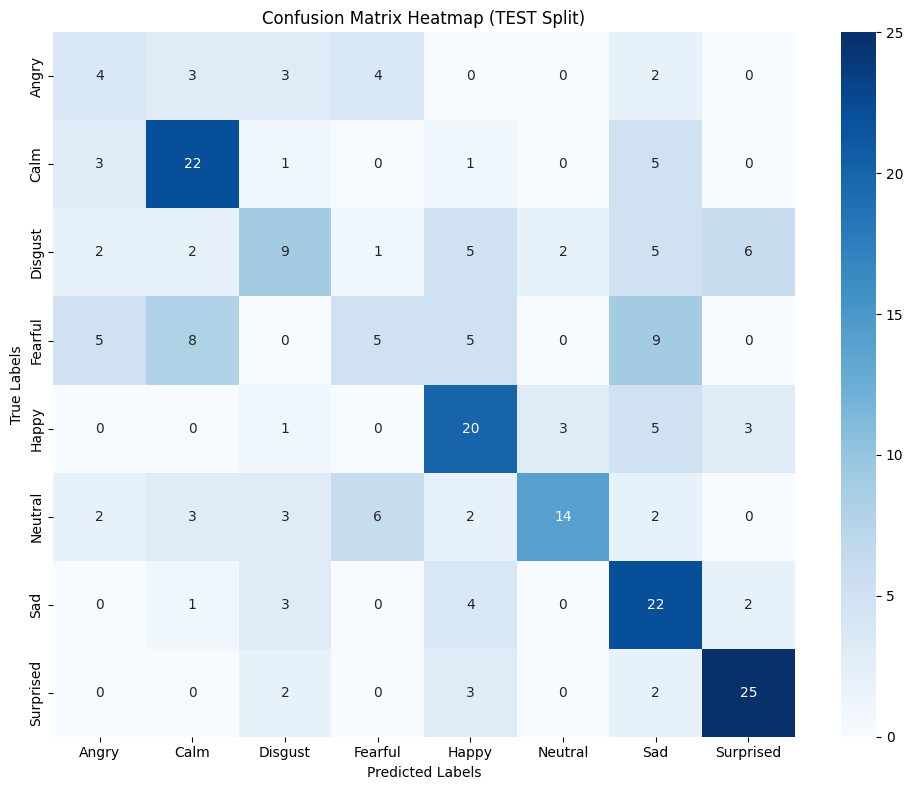

In [ ]:
# Evaluate on the completely unseen test set actors
true_labels, predicted_labels = evaluate_model(
    model=model,
    dataloader=test_loader,
    split_name="TEST"
)


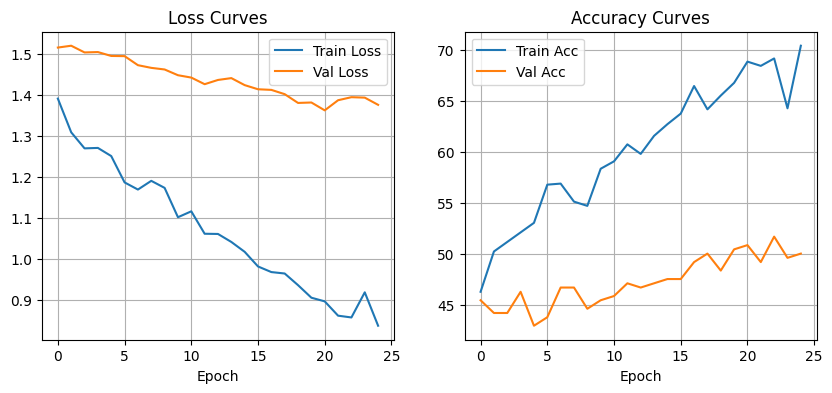

In [ ]:

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

ax1.plot(history_phase2['train_loss'], label='Train Loss')
ax1.plot(history_phase2['val_loss'],   label='Val Loss')
ax1.set_title('Loss Curves')
ax1.set_xlabel('Epoch')
ax1.grid()
ax1.legend()

ax2.plot(history_phase2['train_acc'], label='Train Acc')
ax2.plot(history_phase2['val_acc'],   label='Val Acc')
ax2.set_title('Accuracy Curves')
ax2.set_xlabel('Epoch')
ax2.grid()
ax2.legend()

plt.show()

In [ ]:
model.eval()
test_correct, test_loss = 0, 0
with torch.inference_mode():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item()
        test_correct += (outputs.argmax(1) == labels).sum().item()

test_acc = 100 * test_correct /len(test_loader.dataset)
test_loss_avg = test_loss / len(test_loader)
print(f"Test-acc: {test_acc:.2f} | Test-loss: {test_loss_avg:.4f}")

Test-acc: 50.42 | Test-loss: 1.4503
